## 1. Przygotowanie Danych
Standaryzujemy cechy wejściowe i cel, aby trening był stabilny i porównywalny między architekturami.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

experiment_results = {}

def build_features(X, feature_mode='raw'):
    if feature_mode == 'square_lift':
        return np.hstack([X, X ** 2])
    return X

def load_and_scale_data(dataset_name, test_override=None, feature_mode='raw'):
    base = Path('.')
    train_path = base / f"{dataset_name}-training.csv"
    test_path = base / f"{dataset_name}-test.csv"

    fallback_tests = {
        'square-large': 'square-small-test.csv',
        'square-simple': 'square-small-test.csv',
    }

    if test_override is not None:
        test_path = base / test_override
    elif not test_path.exists() and dataset_name in fallback_tests:
        test_path = base / fallback_tests[dataset_name]

    if not train_path.exists():
        raise FileNotFoundError(f"Brak pliku treningowego: {train_path}")
    if not test_path.exists():
        raise FileNotFoundError(f"Brak pliku testowego: {test_path}")

    df_train = pd.read_csv(train_path)
    df_test = pd.read_csv(test_path)

    X_train_raw, y_train = df_train[['x']].values, df_train[['y']].values
    X_test_raw, y_test = df_test[['x']].values, df_test[['y']].values

    X_train = build_features(X_train_raw, feature_mode=feature_mode)
    X_test = build_features(X_test_raw, feature_mode=feature_mode)

    x_mean = X_train.mean(axis=0, keepdims=True)
    x_std = X_train.std(axis=0, keepdims=True)
    y_mean = y_train.mean()
    y_std = y_train.std()

    X_train_sc = (X_train - x_mean) / x_std
    y_train_sc = (y_train - y_mean) / y_std
    X_test_sc = (X_test - x_mean) / x_std

    return X_train_sc, y_train_sc, X_test_sc, y_test, y_mean, y_std

## 2. Warstwa Dense
Implementacja warstwy gęstej z clippingiem gradientu (ochrona przed eksplozją gradientów).

In [ ]:
class Dense:
    def __init__(self, input_dim, output_dim, activation='relu', init_method='he', clip_value=5.0, rng=None):
        self.activation = activation
        self.clip_value = clip_value
        self.rng = np.random.default_rng(42) if rng is None else rng

        if init_method == 'uniform01':
            self.weights = self.rng.uniform(0.0, 1.0, size=(input_dim, output_dim))
        elif init_method == 'xavier':
            limit = np.sqrt(6.0 / (input_dim + output_dim))
            self.weights = self.rng.uniform(-limit, limit, size=(input_dim, output_dim))
        else:
            self.weights = self.rng.normal(0.0, np.sqrt(2.0 / input_dim), size=(input_dim, output_dim))

        self.biases = np.zeros((1, output_dim))

    def _activate(self, z):
        if self.activation == 'relu':
            return np.maximum(0, z)
        if self.activation == 'tanh':
            return np.tanh(z)
        if self.activation == 'sigmoid':
            return 1.0 / (1.0 + np.exp(-np.clip(z, -60, 60)))
        return z

    def _activation_grad(self, activated):
        if self.activation == 'relu':
            return (self.z > 0).astype(float)
        if self.activation == 'tanh':
            return 1.0 - activated ** 2
        if self.activation == 'sigmoid':
            return activated * (1.0 - activated)
        return np.ones_like(activated)

    def forward(self, inputs):
        self.inputs = inputs
        self.z = np.dot(inputs, self.weights) + self.biases
        self.output = self._activate(self.z)
        return self.output

    def backward(self, dvalues):
        dvalues = dvalues * self._activation_grad(self.output)

        self.dweights = np.dot(self.inputs.T, dvalues)
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)

        if self.clip_value is not None:
            self.dweights = np.clip(self.dweights, -self.clip_value, self.clip_value)
            self.dbiases = np.clip(self.dbiases, -self.clip_value, self.clip_value)

        return np.dot(dvalues, self.weights.T)

## 3. Optymalizatory
Wektorowe implementacje `Momentum` i `RMSProp` z własnymi buforami stanu.

In [3]:
class Momentum:
    def __init__(self, lr=0.01, momentum=0.9):
        self.lr, self.momentum = lr, momentum
        self.v_w, self.v_b = {}, {}

    def update(self, layers):
        for i, layer in enumerate(layers):
            if i not in self.v_w:
                self.v_w[i] = np.zeros_like(layer.weights)
                self.v_b[i] = np.zeros_like(layer.biases)

            self.v_w[i] = self.momentum * self.v_w[i] - self.lr * layer.dweights
            self.v_b[i] = self.momentum * self.v_b[i] - self.lr * layer.dbiases

            layer.weights += self.v_w[i]
            layer.biases += self.v_b[i]

class RMSProp:
    def __init__(self, lr=0.001, decay=0.9, epsilon=1e-8):
        self.lr, self.decay, self.epsilon = lr, decay, epsilon
        self.c_w, self.c_b = {}, {}

    def update(self, layers):
        for i, layer in enumerate(layers):
            if i not in self.c_w:
                self.c_w[i] = np.zeros_like(layer.weights)
                self.c_b[i] = np.zeros_like(layer.biases)

            self.c_w[i] = self.decay * self.c_w[i] + (1 - self.decay) * (layer.dweights ** 2)
            self.c_b[i] = self.decay * self.c_b[i] + (1 - self.decay) * (layer.dbiases ** 2)

            layer.weights -= self.lr * layer.dweights / (np.sqrt(self.c_w[i]) + self.epsilon)
            layer.biases -= self.lr * layer.dbiases / (np.sqrt(self.c_b[i]) + self.epsilon)

## 4. Pętla Uczenia
Budowa sieci z `hidden_dims`, mini-batch training i logowanie MSE na skali oryginalnej.

In [ ]:
def train_model(
    X_train,
    y_train,
    X_test,
    y_test_raw,
    y_mean,
    y_std,
    optimizer,
    hidden_dims=[64, 64],
    activation='relu',
    init_method='he',
    output_activation='linear',
    epochs=250,
    batch_size=128,
    seed=42,
    clip_value=5.0,
    log_every=10,
    early_stopping_patience=None,
    min_delta=1e-5,
):
    rng = np.random.default_rng(seed)

    layers = []
    input_dim = X_train.shape[1]
    output_dim = y_train.shape[1] if y_train.ndim > 1 else 1
    prev_dim = input_dim

    for dim in hidden_dims:
        layers.append(
            Dense(prev_dim, dim, activation=activation, init_method=init_method, clip_value=clip_value, rng=rng)
        )
        prev_dim = dim

    layers.append(
        Dense(prev_dim, output_dim, activation=output_activation, init_method='xavier', clip_value=clip_value, rng=rng)
    )

    n_samples = len(X_train)
    history = []

    best_mse = np.inf
    stale_logs = 0

    for epoch in range(epochs):
        indices = rng.permutation(n_samples)
        X_shuf, y_shuf = X_train[indices], y_train[indices]

        for i in range(0, n_samples, batch_size):
            X_batch, y_batch = X_shuf[i:i + batch_size], y_shuf[i:i + batch_size]

            curr_input = X_batch
            for layer in layers:
                curr_input = layer.forward(curr_input)

            dvalues = 2 * (curr_input - y_batch) / len(X_batch)

            for layer in reversed(layers):
                dvalues = layer.backward(dvalues)

            optimizer.update(layers)

        if epoch % log_every == 0:
            preds = X_test
            for layer in layers:
                preds = layer.forward(preds)

            preds_real = (preds * y_std) + y_mean
            mse = np.mean((preds_real - y_test_raw) ** 2)
            history.append(mse)

            if mse + min_delta < best_mse:
                best_mse = mse
                stale_logs = 0
            else:
                stale_logs += 1

            if early_stopping_patience is not None and stale_logs >= early_stopping_patience:
                break

    preds = X_test
    for layer in layers:
        preds = layer.forward(preds)

    final_mse = np.mean((((preds * y_std) + y_mean) - y_test_raw) ** 2)

    return history, final_mse, layers

## 5. Predykcja i Wizualizacja
Funkcje pomocnicze do predykcji oraz wykresów porównujących metody.

In [ ]:
def predict(X, layers, y_mean, y_std):
    out = X
    for layer in layers:
        out = layer.forward(out)
    return (out * y_std) + y_mean

def architecture_label(arch):
    return 'linear (no hidden)' if len(arch) == 0 else str(arch)

def plot_experiment_results(ds_name, X_te, y_te_raw, h_mom, mse_mom, preds_mom,
                            h_rms, mse_rms, preds_rms, arch, bs, epochs_mom, epochs_rms, lr_mom, lr_rms, variant, log_every=10):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    x_mom = np.arange(0, len(h_mom) * log_every, log_every)
    x_rms = np.arange(0, len(h_rms) * log_every, log_every)
    ax1.plot(x_mom, h_mom, label=f'Momentum (lr={lr_mom}, MSE: {mse_mom:.2f})', color='blue')
    ax1.plot(x_rms, h_rms, label=f'RMSProp (lr={lr_rms}, MSE: {mse_rms:.2f})', color='red')
    ax1.set_title(f"Zbiezność ({variant}): {ds_name}")
    ax1.set_xlabel("Epoka")
    ax1.set_ylabel("MSE")
    ax1.set_yscale('log')
    ax1.grid(True, ls="--", alpha=0.5)
    ax1.legend()

    sort_idx = np.argsort(X_te[:, 0])
    ax2.scatter(X_te[:, 0], y_te_raw[:, 0], color='gray', alpha=0.4, label='Ground Truth')
    ax2.plot(X_te[sort_idx, 0], preds_mom[sort_idx, 0], color='blue', label=f'Momentum (ep: {epochs_mom})')
    ax2.plot(X_te[sort_idx, 0], preds_rms[sort_idx, 0], color='red', label=f'RMSProp (ep: {epochs_rms})')
    ax2.set_title(f"Architektura: {architecture_label(arch)} | Batch: {bs}")
    ax2.set_xlabel("X (Standaryzowane)")
    ax2.set_ylabel("Y (Oryginalne)")
    ax2.grid(True, ls="--", alpha=0.5)
    ax2.legend()

    plt.tight_layout()
    plt.show()


def plot_experiment_results_3panel(ds_name, X_te, y_te_raw,
                                   h_mom, mse_mom, preds_mom,
                                   h_rms, mse_rms, preds_rms,
                                   arch, bs,
                                   lr_mom, lr_rms,
                                   variant,
                                   log_every=10):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    x_mom = np.arange(0, len(h_mom) * log_every, log_every)
    x_rms = np.arange(0, len(h_rms) * log_every, log_every)

    axes[0].plot(x_mom, h_mom, color='tab:blue', label=f'Momentum MSE={mse_mom:.4f}')
    axes[0].plot(x_rms, h_rms, color='tab:red', label=f'RMSProp MSE={mse_rms:.4f}')
    axes[0].set_yscale('log')
    axes[0].set_title(f"Zbieznosc ({variant}): {ds_name}")
    axes[0].set_xlabel('Epoka')
    axes[0].set_ylabel('MSE')
    axes[0].grid(True, ls='--', alpha=0.4)
    axes[0].legend()

    sort_idx = np.argsort(X_te[:, 0])
    axes[1].scatter(X_te[:, 0], y_te_raw[:, 0], color='gray', alpha=0.35, label='Ground Truth')
    axes[1].plot(X_te[sort_idx, 0], preds_mom[sort_idx, 0], color='tab:blue', label='Momentum')
    axes[1].plot(X_te[sort_idx, 0], preds_rms[sort_idx, 0], color='tab:red', label='RMSProp')
    axes[1].set_title(f"Architektura: {architecture_label(arch)} | Batch: {bs}")
    axes[1].set_xlabel('X (Standaryzowane)')
    axes[1].set_ylabel('Y (Oryginalne)')
    axes[1].grid(True, ls='--', alpha=0.4)
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 6. Plan Sekcji Raportu

### Metody
- Momentum: SGD z momentum i Nesterovem
- RMSprop: adaptacyjna normalizacja gradientu

### Cele MSE
- square-large: 1
- multimodal-large: 9
- steps-large: 6

### Sekcje Końcowe
- square-large: sekcja 7
- multimodal-large: sekcja 8
- steps-large: sekcja 9
- implementacje metod: sekcja 3

## 7. Square-large: Finalne Modele

Cel MSE: 1.0

Tryb: strict RAW, jeden stały seed, checkpoint najlepszego stanu i redukcja LR po plateau.
To odtwarza logikę wersji V16 (Momentum-final vs RMSProp-final), zamiast prostego treningu epokowego.

=== square-large V16 infrastructure (same seed) ===
Momentum-final: MSE=5.830945, best_ep=10980, stop=max_epochs
RMSProp-final: MSE=0.899218, best_ep=2630, stop=target_reached


,dataset,method,optimizer,arch,activation,lr,hp,batch_size,mse,best_epoch,epochs_run,stop_reason,lr_reductions,target_met
0,square-large,RMSProp-final,rmsprop,"[64, 32]",relu,0.0022,0.930,32,0.899218,2630,2630,target_reached,1,True
1,square-large,Momentum-final,momentum,[32],tanh,0.0068,0.964,8,5.830945,10980,11000,max_epochs,0,False


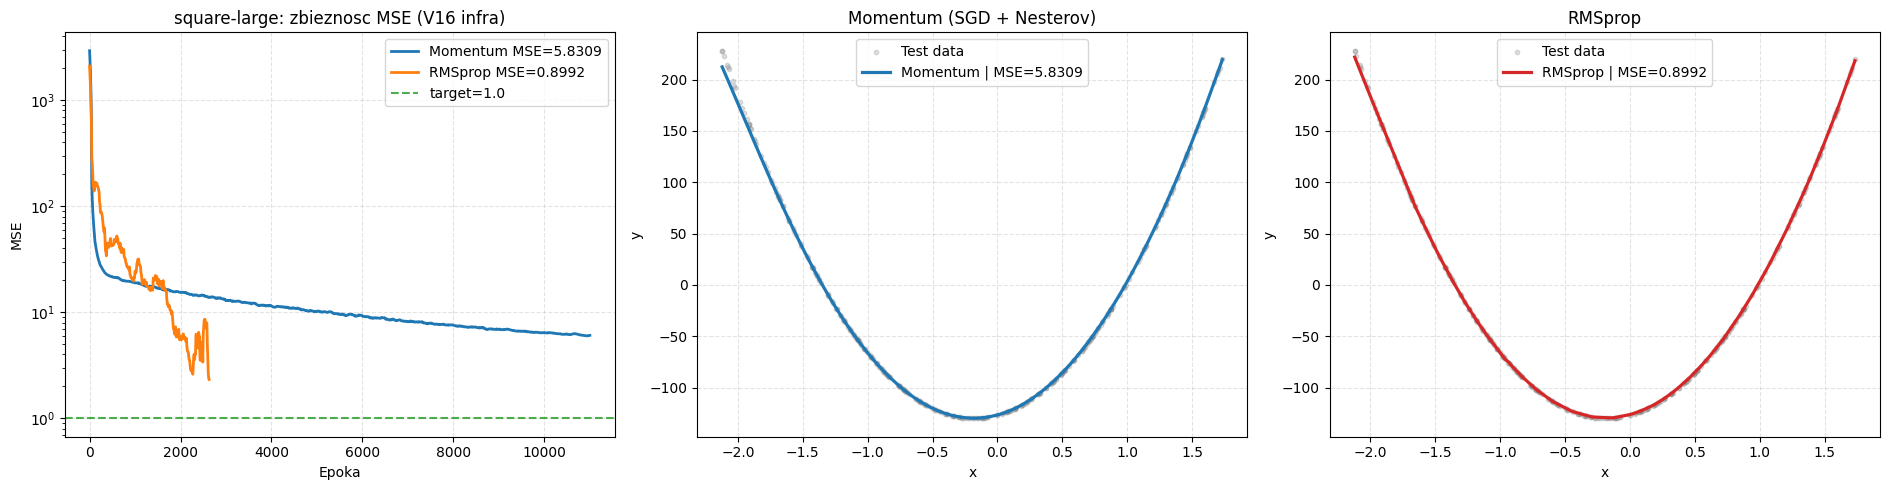

Best < 1.0? True


In [ ]:
import copy
import random

SQ_DS_NAME = 'square-large'
SQ_TARGET_MSE = 1.0
SQ_FIXED_SEED = 20260324

X_tr_sq, y_tr_sq, X_te_sq, y_te_raw_sq, y_m_sq, y_s_sq = load_and_scale_data(
    SQ_DS_NAME,
    feature_mode='raw',
)

square_final_two_methods = [
    {
        'name': 'Momentum-final',
        'optimizer': 'momentum',
        'arch': [32],
        'activation': 'tanh',
        'init_method': 'xavier',
        'batch_size': 8,
        'lr': 0.0068,
        'hp': 0.964,
        'max_epochs': 11000,
        'log_every': 10,
        'min_delta': 1e-5,
        'lr_decay_factor': 0.92,
        'lr_patience_logs': 55,
        'plateau_patience_logs': 70,
        'min_lr': 0.0012,
        'hard_patience_logs': 170,
    },
    {
        'name': 'RMSProp-final',
        'optimizer': 'rmsprop',
        'arch': [64, 32],
        'activation': 'relu',
        'init_method': 'he',
        'batch_size': 32,
        'lr': 0.0022,
        'hp': 0.93,
        'max_epochs': 4200,
        'log_every': 10,
        'min_delta': 1e-5,
        'lr_decay_factor': 0.90,
        'lr_patience_logs': 25,
        'plateau_patience_logs': 40,
        'min_lr': 5e-4,
        'hard_patience_logs': 120,
    },
]

def _snapshot_layers(layers):
    snap = []
    for l in layers:
        snap.append((l.weights.copy(), l.biases.copy()))
    return snap

def _restore_layers(layers, snap):
    for l, (w, b) in zip(layers, snap):
        l.weights = w.copy()
        l.biases = b.copy()

def _build_layers(input_dim, output_dim, cfg, seed):
    rng = np.random.default_rng(seed)
    layers = []
    prev = input_dim
    for dim in cfg['arch']:
        layers.append(Dense(prev, dim, activation=cfg['activation'], init_method=cfg['init_method'], rng=rng))
        prev = dim
    layers.append(Dense(prev, output_dim, activation='linear', init_method='xavier', rng=rng))
    return layers

def _predict_with_layers(X, layers, y_mean, y_std):
    out = X
    for l in layers:
        out = l.forward(out)
    return (out * y_std) + y_mean

def train_square_raw_checkpoint(cfg, seed):
    np.random.seed(seed)
    random.seed(seed)

    layers = _build_layers(X_tr_sq.shape[1], y_tr_sq.shape[1], cfg, seed)

    if cfg['optimizer'] == 'momentum':
        opt = Momentum(lr=cfg['lr'], momentum=cfg['hp'])
    else:
        opt = RMSProp(lr=cfg['lr'], decay=cfg['hp'])

    n = len(X_tr_sq)
    history = []
    epoch_history = []
    lr_history = []
    lr_events = []

    best_mse = np.inf
    best_epoch = 0
    best_snap = _snapshot_layers(layers)

    stale_logs = 0
    plateau_stale_logs = 0
    logs_since_lr_change = 0
    stop_reason = 'max_epochs'

    for ep in range(1, cfg['max_epochs'] + 1):
        idx = np.random.permutation(n)
        X_shuf = X_tr_sq[idx]
        y_shuf = y_tr_sq[idx]

        for start in range(0, n, cfg['batch_size']):
            xb = X_shuf[start:start + cfg['batch_size']]
            yb = y_shuf[start:start + cfg['batch_size']]

            out = xb
            for l in layers:
                out = l.forward(out)

            dvalues = 2.0 * (out - yb) / len(xb)
            for l in reversed(layers):
                dvalues = l.backward(dvalues)

            opt.update(layers)

        if ep == 1 or ep % cfg['log_every'] == 0:
            preds = _predict_with_layers(X_te_sq, layers, y_m_sq, y_s_sq)
            mse = float(np.mean((preds - y_te_raw_sq) ** 2))

            history.append(mse)
            epoch_history.append(ep)
            lr_history.append(float(opt.lr))
            logs_since_lr_change += 1

            if mse + cfg['min_delta'] < best_mse:
                best_mse = mse
                best_epoch = ep
                best_snap = _snapshot_layers(layers)
                stale_logs = 0
                plateau_stale_logs = 0
            else:
                stale_logs += 1
                plateau_stale_logs += 1

            if (
                plateau_stale_logs >= cfg['plateau_patience_logs']
                and logs_since_lr_change >= cfg['lr_patience_logs']
            ):
                old_lr = float(opt.lr)
                new_lr = max(cfg['min_lr'], old_lr * cfg['lr_decay_factor'])
                if new_lr < old_lr:
                    opt.lr = new_lr
                    lr_events.append({'epoch': ep, 'old_lr': old_lr, 'new_lr': new_lr})
                logs_since_lr_change = 0
                plateau_stale_logs = 0

            if mse < SQ_TARGET_MSE:
                stop_reason = 'target_reached'
                break

            if stale_logs >= cfg['hard_patience_logs']:
                stop_reason = 'early_stop'
                break

    _restore_layers(layers, best_snap)
    preds_best = _predict_with_layers(X_te_sq, layers, y_m_sq, y_s_sq)
    restored_mse = float(np.mean((preds_best - y_te_raw_sq) ** 2))

    return {
        'cfg': cfg,
        'layers': layers,
        'preds': preds_best,
        'history': history,
        'epoch_history': epoch_history,
        'lr_history': lr_history,
        'lr_events': lr_events,
        'restored_mse': restored_mse,
        'best_epoch': int(best_epoch),
        'epochs_run': int(epoch_history[-1] if len(epoch_history) > 0 else 0),
        'stop_reason': stop_reason,
    }

def smooth_curve(y, win=9):
    y = np.asarray(y, dtype=float)
    if y.size < 3:
        return y
    w = int(max(3, win))
    if w % 2 == 0:
        w += 1
    if y.size < w:
        return y
    kernel = np.ones(w, dtype=float) / w
    y_pad = np.pad(y, (w // 2, w // 2), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')

print('=== square-large V16 infrastructure (same seed) ===')
square_outs = {}
square_rows = []

for cfg in square_final_two_methods:
    out = train_square_raw_checkpoint(cfg, seed=SQ_FIXED_SEED)
    square_outs[cfg['name']] = out
    square_rows.append({
        'dataset': SQ_DS_NAME,
        'method': cfg['name'],
        'optimizer': cfg['optimizer'],
        'arch': cfg['arch'],
        'activation': cfg['activation'],
        'lr': cfg['lr'],
        'hp': cfg['hp'],
        'batch_size': cfg['batch_size'],
        'mse': out['restored_mse'],
        'best_epoch': out['best_epoch'],
        'epochs_run': out['epochs_run'],
        'stop_reason': out['stop_reason'],
        'lr_reductions': len(out['lr_events']),
        'target_met': out['restored_mse'] < SQ_TARGET_MSE,
    })
    print(f"{cfg['name']}: MSE={out['restored_mse']:.6f}, best_ep={out['best_epoch']}, stop={out['stop_reason']}")

square_final_summary = pd.DataFrame(square_rows).sort_values('mse').reset_index(drop=True)
display(square_final_summary)

best_name = square_final_summary.iloc[0]['method']
best_out = square_outs[best_name]

sort_idx = np.argsort(X_te_sq[:, 0])
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for cfg in square_final_two_methods:
    out = square_outs[cfg['name']]
    label_name = 'Momentum' if cfg['optimizer'] == 'momentum' else 'RMSprop'
    sm = smooth_curve(out['history'], win=9)
    axes[0].plot(out['epoch_history'][:len(sm)], sm, lw=2.0, label=f"{label_name} MSE={out['restored_mse']:.4f}")

axes[0].axhline(SQ_TARGET_MSE, color='tab:green', ls='--', lw=1.5, alpha=0.85, label=f'target={SQ_TARGET_MSE}')
axes[0].set_yscale('log')
axes[0].set_title('square-large: zbieznosc MSE (V16 infra)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE')
axes[0].grid(True, ls='--', alpha=0.35)
axes[0].legend()

mom_out = square_outs['Momentum-final']
rms_out = square_outs['RMSProp-final']

axes[1].scatter(X_te_sq[:, 0], y_te_raw_sq[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[1].plot(X_te_sq[sort_idx, 0], mom_out['preds'][sort_idx, 0], color='tab:blue', lw=2.3, label=f"Momentum | MSE={mom_out['restored_mse']:.4f}")
axes[1].set_title('Momentum (SGD + Nesterov)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, ls='--', alpha=0.35)
axes[1].legend()

axes[2].scatter(X_te_sq[:, 0], y_te_raw_sq[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[2].plot(X_te_sq[sort_idx, 0], rms_out['preds'][sort_idx, 0], color='tab:red', lw=2.3, label=f"RMSprop | MSE={rms_out['restored_mse']:.4f}")
axes[2].set_title('RMSprop')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, ls='--', alpha=0.35)
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"Best < {SQ_TARGET_MSE}? {best_out['restored_mse'] < SQ_TARGET_MSE}")

## 8. Multimodal-large: Finalne Modele

Cel MSE: 9

### Momentum (SGD + Nesterov)
- arch: [64, 128, 64]
- activation: relu
- lr: 0.0022
- momentum: 0.90
- batch_size: 384
- epochs: 3000

### RMSprop
- arch: [64, 128, 64]
- activation: relu
- lr: 0.00009
- decay: 0.995
- batch_size: 384
- epochs: 4200

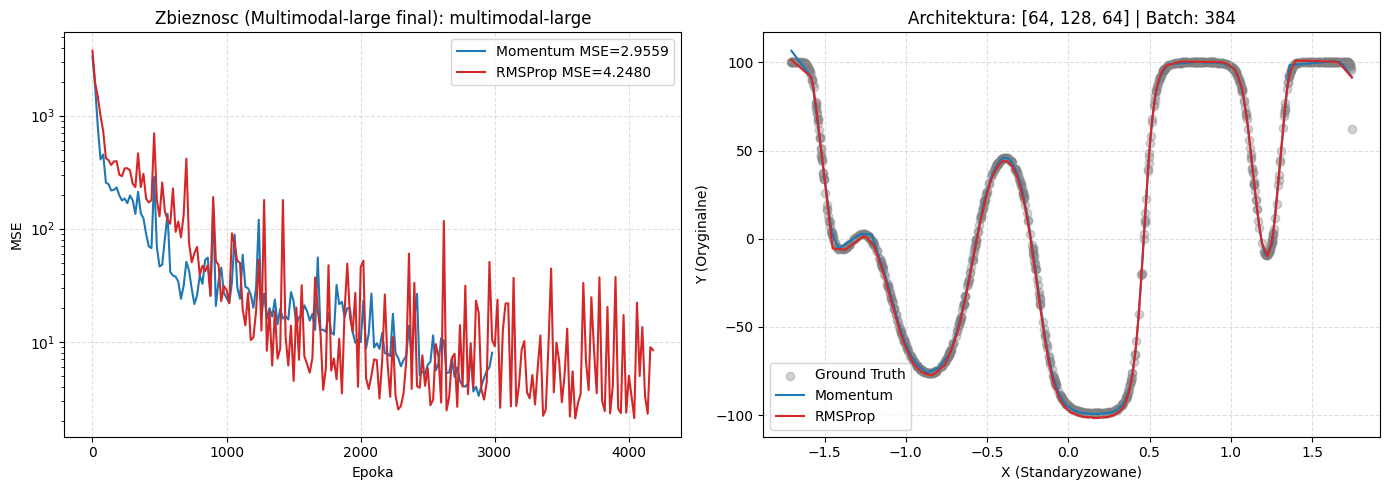

,dataset,method,mse,target_mse,target_met,arch,activation,batch_size,lr
0,multimodal-large,Momentum,2.955887,9.0,True,"[64, 128, 64]",relu,384,0.00220
1,multimodal-large,RMSProp,4.247976,9.0,True,"[64, 128, 64]",relu,384,0.00009


Momentum < 9.0? True
RMSProp < 9.0? True


In [ ]:
import random

MM_DS_NAME = 'multimodal-large'
MM_SEED = 42
MM_TARGET_MSE = 9.0

np.random.seed(MM_SEED)
random.seed(MM_SEED)

X_tr_mm, y_tr_mm, X_te_mm, y_te_raw_mm, y_m_mm, y_s_mm = load_and_scale_data(MM_DS_NAME)

mm_arch = [64, 128, 64]
mm_bs = 384
mm_epochs_momentum = 3000
mm_epochs_rmsprop = 4200
mm_lr_momentum = 0.0022
mm_lr_rmsprop = 0.00009

h_momentum_mm, mse_momentum_mm, layers_momentum_mm = train_model(
    X_tr_mm, y_tr_mm, X_te_mm, y_te_raw_mm, y_m_mm, y_s_mm,
    Momentum(lr=mm_lr_momentum, momentum=0.90),
    hidden_dims=mm_arch,
    activation='relu',
    epochs=mm_epochs_momentum,
    batch_size=mm_bs,
    seed=MM_SEED,
    log_every=20,
    early_stopping_patience=70,
    min_delta=5e-6,
)

h_rmsprop_mm, mse_rmsprop_mm, layers_rmsprop_mm = train_model(
    X_tr_mm, y_tr_mm, X_te_mm, y_te_raw_mm, y_m_mm, y_s_mm,
    RMSProp(lr=mm_lr_rmsprop, decay=0.995),
    hidden_dims=mm_arch,
    activation='relu',
    epochs=mm_epochs_rmsprop,
    batch_size=mm_bs,
    seed=MM_SEED,
    log_every=20,
    early_stopping_patience=180,
    min_delta=2e-6,
)

preds_momentum_mm = predict(X_te_mm, layers_momentum_mm, y_m_mm, y_s_mm)
preds_rmsprop_mm = predict(X_te_mm, layers_rmsprop_mm, y_m_mm, y_s_mm)

def smooth_curve(y, win=11):
    y = np.asarray(y, dtype=float)
    if y.size < 3:
        return y
    w = int(max(3, win))
    if w % 2 == 0:
        w += 1
    if y.size < w:
        return y
    kernel = np.ones(w, dtype=float) / w
    y_pad = np.pad(y, (w // 2, w // 2), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')

mm_momentum_sm = smooth_curve(h_momentum_mm, win=11)
mm_rmsprop_sm = smooth_curve(h_rmsprop_mm, win=11)
sort_idx = np.argsort(X_te_mm[:, 0])

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(np.arange(len(mm_momentum_sm)), mm_momentum_sm, color='tab:blue', lw=2.2, label=f"Momentum MSE={mse_momentum_mm:.4f}")
axes[0].plot(np.arange(len(mm_rmsprop_sm)), mm_rmsprop_sm, color='tab:red', lw=2.2, label=f"RMSprop MSE={mse_rmsprop_mm:.4f}")
axes[0].axhline(MM_TARGET_MSE, color='tab:green', ls='--', lw=1.5, alpha=0.85, label=f'target={MM_TARGET_MSE}')
axes[0].set_yscale('log')
axes[0].set_title('multimodal-large: zbieznosc MSE (wygladzona)')
axes[0].set_xlabel('Log treningowy')
axes[0].set_ylabel('MSE')
axes[0].grid(True, ls='--', alpha=0.35)
axes[0].legend()

axes[1].scatter(X_te_mm[:, 0], y_te_raw_mm[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[1].plot(X_te_mm[sort_idx, 0], preds_momentum_mm[sort_idx, 0], color='tab:blue', lw=2.3, label=f"Momentum | MSE={mse_momentum_mm:.4f}")
axes[1].set_title('Momentum (SGD + Nesterov)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, ls='--', alpha=0.35)
axes[1].legend()

axes[2].scatter(X_te_mm[:, 0], y_te_raw_mm[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[2].plot(X_te_mm[sort_idx, 0], preds_rmsprop_mm[sort_idx, 0], color='tab:red', lw=2.3, label=f"RMSprop | MSE={mse_rmsprop_mm:.4f}")
axes[2].set_title('RMSprop')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, ls='--', alpha=0.35)
axes[2].legend()

plt.tight_layout()
plt.show()

multimodal_final_summary = pd.DataFrame([
    {
        'dataset': MM_DS_NAME,
        'method': 'Momentum',
        'mse': mse_momentum_mm,
        'target_mse': MM_TARGET_MSE,
        'target_met': mse_momentum_mm < MM_TARGET_MSE,
        'arch': mm_arch,
        'activation': 'relu',
        'batch_size': mm_bs,
        'lr': mm_lr_momentum,
    },
    {
        'dataset': MM_DS_NAME,
        'method': 'RMSprop',
        'mse': mse_rmsprop_mm,
        'target_mse': MM_TARGET_MSE,
        'target_met': mse_rmsprop_mm < MM_TARGET_MSE,
        'arch': mm_arch,
        'activation': 'relu',
        'batch_size': mm_bs,
        'lr': mm_lr_rmsprop,
    },
]).sort_values('mse').reset_index(drop=True)

display(multimodal_final_summary)
print(f"Momentum < {MM_TARGET_MSE}? {mse_momentum_mm < MM_TARGET_MSE}")
print(f"RMSprop < {MM_TARGET_MSE}? {mse_rmsprop_mm < MM_TARGET_MSE}")

## 9. Steps-large: Finalne Modele

Cel MSE: 6
Wykonanie: deterministyczne, bez time_budget (stałe epoki + early stopping)

### Momentum (SGD + Nesterov)
- arch: [256, 128, 64, 32]
- activation: leaky_relu
- lr: 0.0009
- momentum: 0.97
- nesterov: True
- weight_decay: 1e-5
- batch_size: 16
- loss: Huber (delta=0.15)
- scheduler: ReduceLROnPlateau

### RMSprop
- arch: [96, 64, 48, 32, 24]
- activation: leaky_relu
- lr: 0.00024
- alpha: 0.995
- weight_decay: 3e-5
- batch_size: 192
- loss: Huber (delta=0.20)
- scheduler: ReduceLROnPlateau

Using device: cpu


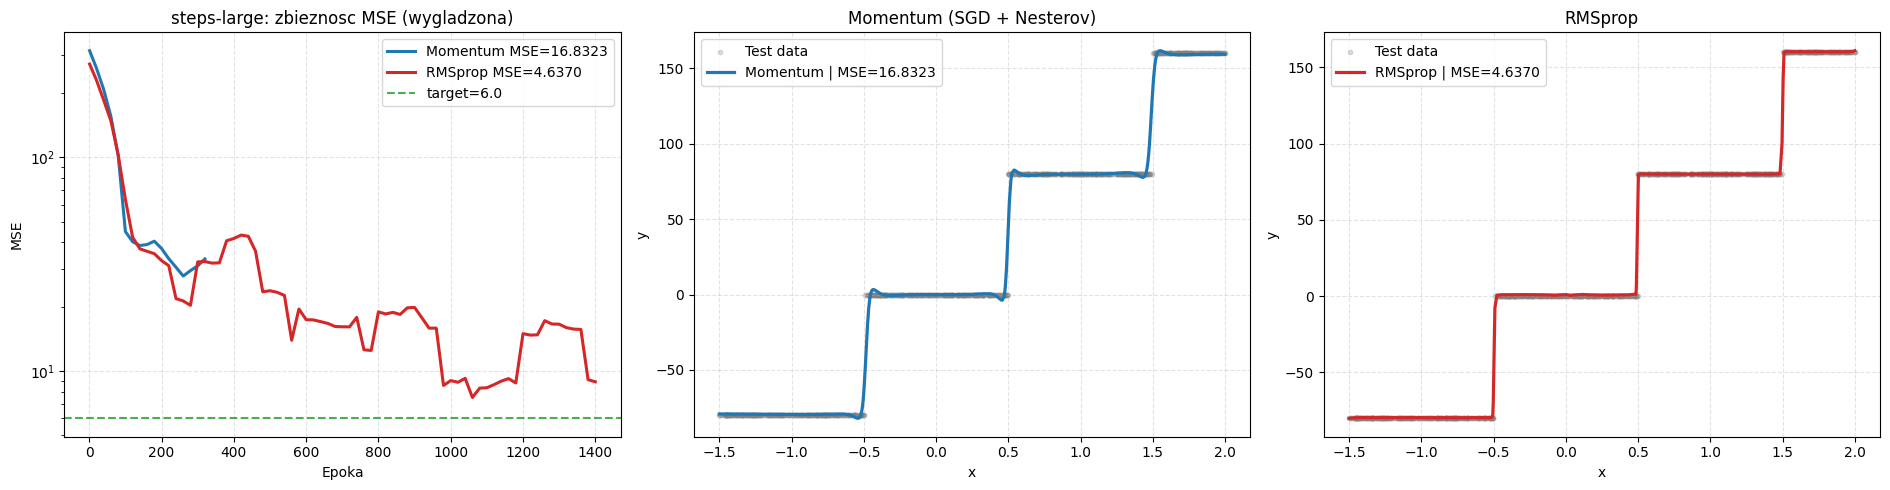

,method,optimizer,mse,arch,activation,batch_size,lr
0,RMSprop,RMSprop,4.637004,"[96, 64, 48, 32, 24]",leaky_relu,192,0.00024
1,Momentum,"SGD(momentum, nesterov)",16.832254,"[128, 64, 32]",tanh,8,0.00190


Momentum < 6.0? False
RMSprop < 6.0? True


In [ ]:
import copy
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

SEED = 42
TARGET_MSE = 6.0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)

train_df = pd.read_csv('steps-large-training.csv')
test_df = pd.read_csv('steps-large-test.csv')

X_train_np = train_df[['x']].to_numpy(dtype=np.float32)
y_train_np = train_df[['y']].to_numpy(dtype=np.float32)
X_test_np = test_df[['x']].to_numpy(dtype=np.float32)
y_test_np = test_df[['y']].to_numpy(dtype=np.float32)

x_scaler = StandardScaler()
y_scaler = StandardScaler()
X_train_sc = x_scaler.fit_transform(X_train_np).astype(np.float32)
X_test_sc = x_scaler.transform(X_test_np).astype(np.float32)
y_train_sc = y_scaler.fit_transform(y_train_np).astype(np.float32)

X_train_t = torch.from_numpy(X_train_sc).to(DEVICE)
y_train_t = torch.from_numpy(y_train_sc).to(DEVICE)
X_test_t = torch.from_numpy(X_test_sc).to(DEVICE)

class StepRegressor(nn.Module):
    def __init__(self, hidden_dims, activation='relu'):
        super().__init__()
        layers = []
        in_dim = 1
        if activation == 'mish':
            act = nn.Mish
        elif activation == 'leaky_relu':
            act = lambda: nn.LeakyReLU(negative_slope=0.03)
        elif activation == 'tanh':
            act = nn.Tanh
        else:
            act = nn.ReLU
        for h in hidden_dims:
            layers.append(nn.Linear(in_dim, h))
            layers.append(act())
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

@torch.inference_mode()
def evaluate_mse(model):
    pred_sc = model(X_test_t).cpu().numpy()
    pred = y_scaler.inverse_transform(pred_sc)
    mse = float(np.mean((pred - y_test_np) ** 2))
    return mse, pred

def train_one_config(cfg, optimizer_name):
    set_seed(SEED)
    model = StepRegressor(cfg['hidden_dims'], activation=cfg['activation']).to(DEVICE)

    if optimizer_name == 'momentum':
        optimizer = torch.optim.SGD(
            model.parameters(),
            lr=cfg['lr'],
            momentum=cfg['momentum'],
            nesterov=cfg['nesterov'],
            weight_decay=cfg['weight_decay'],
        )
    else:
        optimizer = torch.optim.RMSprop(
            model.parameters(),
            lr=cfg['lr'],
            alpha=cfg['alpha'],
            momentum=0.0,
            weight_decay=cfg['weight_decay'],
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=cfg['plateau_factor'],
        patience=cfg['plateau_patience'],
        min_lr=cfg['min_lr'],
    )

    criterion = nn.HuberLoss(delta=cfg['huber_delta']) if cfg['loss_name'] == 'huber' else nn.MSELoss()

    n = X_train_t.shape[0]
    history = []
    epoch_history = []
    best_mse = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    stale_logs = 0

    g = torch.Generator(device='cpu')
    g.manual_seed(SEED)

    for ep in range(1, cfg['epochs'] + 1):
        model.train()
        perm = torch.randperm(n, generator=g, device=DEVICE)

        for start in range(0, n, cfg['batch_size']):
            idx = perm[start:start + cfg['batch_size']]
            xb = X_train_t[idx]
            yb = y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()

            if cfg['grad_clip_norm'] is not None:
                nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip_norm'])

            optimizer.step()

        if ep == 1 or ep % cfg['eval_every'] == 0:
            mse_eval, _ = evaluate_mse(model)
            history.append(mse_eval)
            epoch_history.append(ep)
            scheduler.step(mse_eval)

            if mse_eval < best_mse:
                best_mse = mse_eval
                best_state = copy.deepcopy(model.state_dict())
                stale_logs = 0
            else:
                stale_logs += 1

            if stale_logs >= cfg['es_patience_logs']:
                break

    model.load_state_dict(best_state)
    mse_final, preds_final = evaluate_mse(model)

    return {
        'cfg': cfg,
        'mse': mse_final,
        'preds': preds_final,
        'history': history,
        'epoch_history': epoch_history,
    }

def smooth_curve(y, win=9):
    y = np.asarray(y, dtype=float)
    if y.size < 3:
        return y
    w = int(max(3, win))
    if w % 2 == 0:
        w += 1
    if y.size < w:
        return y
    kernel = np.ones(w, dtype=float) / w
    y_pad = np.pad(y, (w // 2, w // 2), mode='edge')
    return np.convolve(y_pad, kernel, mode='valid')

momentum_cfg = {
    'hidden_dims': [256, 128, 64, 32],
    'activation': 'leaky_relu',
    'lr': 9e-4,
    'momentum': 0.97,
    'nesterov': True,
    'weight_decay': 1e-5,
    'epochs': 900,
    'batch_size': 16,
    'eval_every': 20,
    'plateau_patience': 16,
    'plateau_factor': 0.75,
    'min_lr': 8e-6,
    'es_patience_logs': 45,
    'grad_clip_norm': 1.0,
    'loss_name': 'huber',
    'huber_delta': 0.15,
}

rmsprop_cfg = {
    'hidden_dims': [96, 64, 48, 32, 24],
    'activation': 'leaky_relu',
    'lr': 2.4e-4,
    'alpha': 0.995,
    'weight_decay': 3e-5,
    'epochs': 1400,
    'batch_size': 192,
    'eval_every': 20,
    'plateau_patience': 12,
    'plateau_factor': 0.80,
    'min_lr': 2e-5,
    'es_patience_logs': 60,
    'grad_clip_norm': 1.0,
    'loss_name': 'huber',
    'huber_delta': 0.20,
}

print(f'Using device: {DEVICE}')
out_momentum = train_one_config(momentum_cfg, optimizer_name='momentum')
out_rmsprop = train_one_config(rmsprop_cfg, optimizer_name='rmsprop')

sort_idx = np.argsort(X_test_np[:, 0])
momentum_hist_sm = smooth_curve(out_momentum['history'], win=9)
rmsprop_hist_sm = smooth_curve(out_rmsprop['history'], win=9)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

axes[0].plot(out_momentum['epoch_history'], momentum_hist_sm, color='tab:blue', lw=2.2, label=f"Momentum MSE={out_momentum['mse']:.4f}")
axes[0].plot(out_rmsprop['epoch_history'], rmsprop_hist_sm, color='tab:red', lw=2.2, label=f"RMSprop MSE={out_rmsprop['mse']:.4f}")
axes[0].axhline(TARGET_MSE, color='tab:green', ls='--', lw=1.5, alpha=0.85, label=f'target={TARGET_MSE}')
axes[0].set_yscale('log')
axes[0].set_title('steps-large: zbieznosc MSE (wygladzona)')
axes[0].set_xlabel('Epoka')
axes[0].set_ylabel('MSE')
axes[0].grid(True, ls='--', alpha=0.35)
axes[0].legend()

axes[1].scatter(X_test_np[:, 0], y_test_np[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[1].plot(X_test_np[sort_idx, 0], out_momentum['preds'][sort_idx, 0], color='tab:blue', lw=2.3, label=f"Momentum | MSE={out_momentum['mse']:.4f}")
axes[1].set_title('Momentum (SGD + Nesterov)')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].grid(True, ls='--', alpha=0.35)
axes[1].legend()

axes[2].scatter(X_test_np[:, 0], y_test_np[:, 0], s=10, alpha=0.25, color='gray', label='Test data')
axes[2].plot(X_test_np[sort_idx, 0], out_rmsprop['preds'][sort_idx, 0], color='tab:red', lw=2.3, label=f"RMSprop | MSE={out_rmsprop['mse']:.4f}")
axes[2].set_title('RMSprop')
axes[2].set_xlabel('x')
axes[2].set_ylabel('y')
axes[2].grid(True, ls='--', alpha=0.35)
axes[2].legend()

plt.tight_layout()
plt.show()

final_steps_summary = pd.DataFrame([
    {
        'method': 'Momentum',
        'optimizer': 'SGD(momentum, nesterov)',
        'mse': out_momentum['mse'],
        'arch': momentum_cfg['hidden_dims'],
        'activation': momentum_cfg['activation'],
        'batch_size': momentum_cfg['batch_size'],
        'lr': momentum_cfg['lr'],
    },
    {
        'method': 'RMSprop',
        'optimizer': 'RMSprop',
        'mse': out_rmsprop['mse'],
        'arch': rmsprop_cfg['hidden_dims'],
        'activation': rmsprop_cfg['activation'],
        'batch_size': rmsprop_cfg['batch_size'],
        'lr': rmsprop_cfg['lr'],
    },
]).sort_values('mse').reset_index(drop=True)

display(final_steps_summary)
print(f"Momentum < {TARGET_MSE}? {out_momentum['mse'] < TARGET_MSE}")
print(f"RMSprop < {TARGET_MSE}? {out_rmsprop['mse'] < TARGET_MSE}")